In [1]:
import numpy as np
np.random.seed(1)
import os
import sys
import matplotlib.pyplot as plt
# Get the directory where the current notebook is located
NOTEBOOK_DIR = os.getcwd()

# Go up two levels (adjust the '..' count as needed)
REPO_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '../'))

# Add to sys.path if not already there
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
from DisTreebution.UQ.UQ import UQ
import matplotlib

# Loading data

In [2]:
def get_data(mode='smooth', n=100, seed=10):
    np.random.seed(seed)
    X = np.random.uniform(0, 10, n)
    a = X*(X>1)+(X<=1)
    scale = (a<6)*a+6*(a>=6)
    y = np.random.gamma(np.sqrt(X), scale=scale)
    if mode=='smooth':
        return X.reshape(-1,1), y
    elif mode=='discontinuous':
        return X.reshape(-1,1), (y+10*(X>=5))
    elif mode=='non-isotonic':
        return X.reshape(-1,1), ((y-2*(X>=7)))
    elif mode=='discrete':
        return X.reshape(-1,1), np.random.poisson(scale, size=n)

from scipy.stats import gamma, poisson
def get_cdf(x_i, vals, mode='smooth'):
    a = x_i*(x_i>1)+(x_i<=1)
    scale = (a<6)*a+6*(a>=6)
    gdcf = gamma.cdf(vals, np.sqrt(x_i), scale=scale)
    if mode=='smooth':
        return gdcf
    elif mode=='discontinuous':
        if x_i<5:
            return gdcf
        else:
            return gamma.cdf(vals-10, np.sqrt(x_i), scale=scale)
    elif mode=='non-isotonic':
        if x_i<7:
            return gdcf
        else:
            return gamma.cdf(vals+2, np.sqrt(x_i), scale=scale)
    elif mode=='discrete':
        return poisson.cdf(vals, scale)

mode = 'smooth'
X, y = get_data(mode=mode, n=600, seed=20)

# CRPS-RF

100%|██████████| 100/100 [00:19<00:00,  5.01it/s]
/tmp/ipykernel_1535/2928875986.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('Greys')


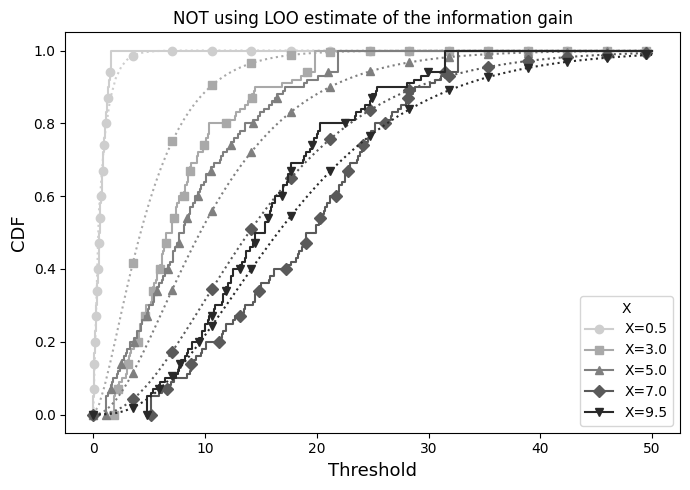

100%|██████████| 100/100 [00:13<00:00,  7.24it/s]


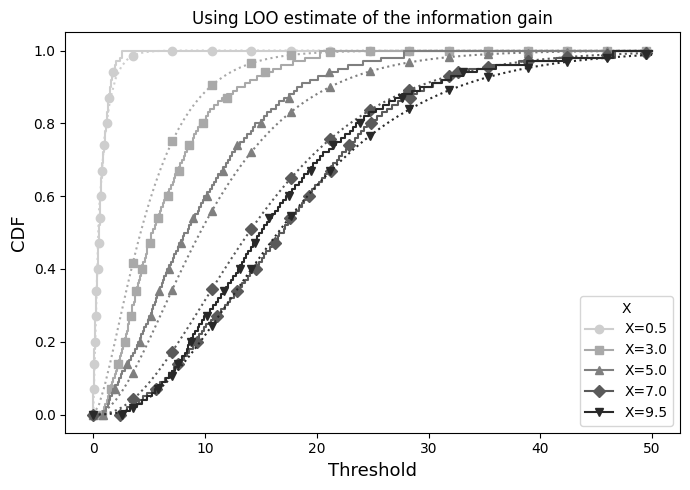

In [3]:
ls_q = [0.01*(i+1) for i in range(99)]
markers = ['o', 's', '^', 'D', 'v']  # distinct markers for each x_test
styles = ['-', '--', ':', '-.', (0, (3, 10, 1, 10))]

for use_LOO in [False, True]:
    if not(use_LOO):
        IG_mode = None
    else:
        IG_mode = "LOO"
    params = {'IG_biais_correction':IG_mode, 'nTrees':100, 'max_depth':10, 'min_samples_split':10}

    model = UQ(type_tree='CRPS', type_conformal=None, params=params)
    treesCRPSRT, _ = model.train_trees(X.reshape(-1,1), y)

    x_test = np.array([0.5, 3, 5, 7, 9.5]).reshape(-1,1)
    resCRPSRT = model.get_quantile_estimate(treesCRPSRT, x_test, ls_q)

    plt.figure(figsize=(7,5))

    # Use a sequential gray colormap
    cmap = matplotlib.cm.get_cmap('Greys')

    for i, x_i in enumerate(x_test[:,0]):
        ls_x = []
        ls_y = []
        for i_q, q in enumerate(ls_q[:-1]):
            ls_x += [resCRPSRT[i][i_q], resCRPSRT[i][i_q], resCRPSRT[i][i_q+1]]
            if i_q==0:
                ls_y += [0, q, q]
            else:
                ls_y += [ls_q[i_q-1], q, q]
        ls_x.append(resCRPSRT[i][len(ls_q)-1])
        ls_y.append(1)
        ls_x.append(50)
        ls_y.append(1)

        color = cmap(0.3 + 0.7 * i / x_test.shape[0])  # shades of gray
        plt.plot(ls_x, ls_y, color=color, linestyle='-', marker=markers[i % len(markers)],
                 markevery=20, markersize=6, label=f'X={x_i}')

        # Theoretical CDF as dotted line with same shade
        vals = np.linspace(0,50,100)
        plt.plot(vals, get_cdf(x_i, vals, mode=mode), color=color, marker=markers[i % len(markers)], markevery=7, linestyle=':')

    plt.legend(title='X', fontsize=10)
    plt.xlabel('Threshold', fontsize=13)
    plt.ylabel('CDF', fontsize=13)

    if use_LOO:
        plt.title('Using LOO estimate of the information gain')
    else:
        plt.title('NOT using LOO estimate of the information gain')
    plt.tight_layout()
    plt.savefig(f'LOO_{use_LOO}.png', dpi=250, bbox_inches="tight")
    plt.show()

# PMQRF

100%|█████████████████████████████████████████| 100/100 [05:35<00:00,  3.36s/it]
/tmp/ipykernel_6936/1492875222.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = matplotlib.cm.get_cmap('Greys')


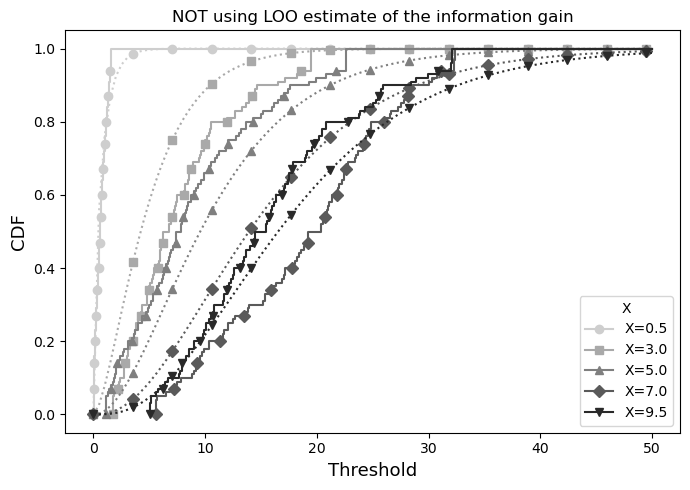

100%|█████████████████████████████████████████| 100/100 [07:31<00:00,  4.51s/it]


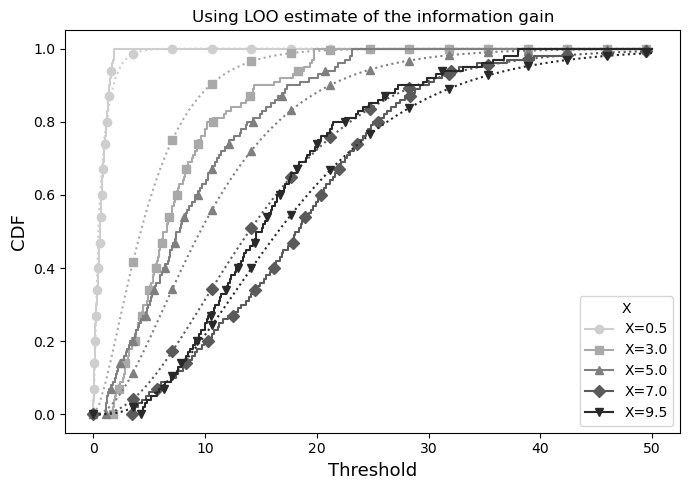

In [7]:
ls_q = [0.01*(i+1) for i in range(99)]
markers = ['o', 's', '^', 'D', 'v']  # distinct markers for each x_test
styles = ['-', '--', ':', '-.', (0, (3, 10, 1, 10))]

for use_LOO in [False, True]:
    if not(use_LOO):
        IG_mode = None
    else:
        IG_mode = "LOO"
    params = {'IG_biais_correction':IG_mode, 'nTrees':100, 'max_depth':10, 'min_samples_split':10,
             'treeID2quantiles_train': {i: ls_q for i in range(100)}}

    model = UQ(type_tree='PMQRT', type_conformal=None, params=params)
    treesCRPSRT, _ = model.train_trees(X.reshape(-1,1), y)

    x_test = np.array([0.5, 3, 5, 7, 9.5]).reshape(-1,1)
    resCRPSRT = model.get_quantile_estimate(treesCRPSRT, x_test, ls_q)

    plt.figure(figsize=(7,5))

    # Use a sequential gray colormap
    cmap = matplotlib.cm.get_cmap('Greys')

    for i, x_i in enumerate(x_test[:,0]):
        ls_x = []
        ls_y = []
        for i_q, q in enumerate(ls_q[:-1]):
            ls_x += [resCRPSRT[i][i_q], resCRPSRT[i][i_q], resCRPSRT[i][i_q+1]]
            if i_q==0:
                ls_y += [0, q, q]
            else:
                ls_y += [ls_q[i_q-1], q, q]
        ls_x.append(resCRPSRT[i][len(ls_q)-1])
        ls_y.append(1)
        ls_x.append(50)
        ls_y.append(1)

        color = cmap(0.3 + 0.7 * i / x_test.shape[0])  # shades of gray
        plt.plot(ls_x, ls_y, color=color, linestyle='-', marker=markers[i % len(markers)],
                 markevery=20, markersize=6, label=f'X={x_i}')

        # Theoretical CDF as dotted line with same shade
        vals = np.linspace(0,50,100)
        plt.plot(vals, get_cdf(x_i, vals, mode=mode), color=color, marker=markers[i % len(markers)], markevery=7, linestyle=':')

    plt.legend(title='X', fontsize=10)
    plt.xlabel('Threshold', fontsize=13)
    plt.ylabel('CDF', fontsize=13)

    if use_LOO:
        plt.title('Using LOO estimate of the information gain')
    else:
        plt.title('NOT using LOO estimate of the information gain')
    plt.tight_layout()
    plt.savefig(f'LOO_{use_LOO}.png', dpi=250, bbox_inches="tight")
    plt.show()

# Quantile Random Forest (for comparison) 

/tmp/ipykernel_9750/1027012854.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = matplotlib.cm.get_cmap('Greys')


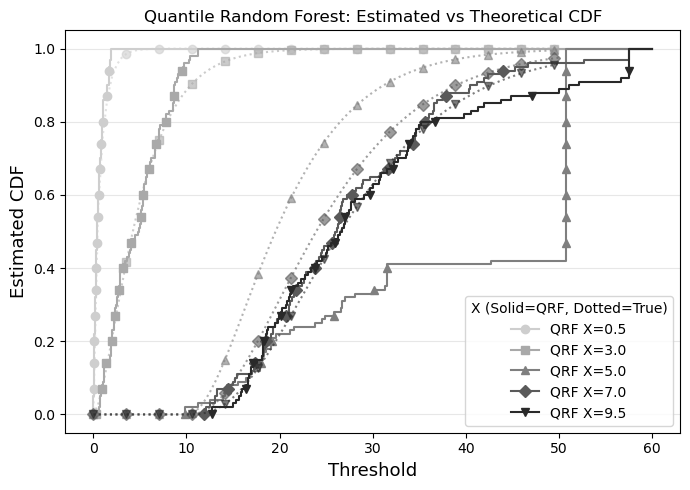

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm
from quantile_forest import RandomForestQuantileRegressor

# 1. Setup Parameters
ls_q = [0.01 * (i + 1) for i in range(99)]
x_test = np.array([0.5, 3, 5, 7, 9.5]).reshape(-1, 1)
markers = ['o', 's', '^', 'D', 'v']

# Note: QRF doesn't typically use "LOO Information Gain" in the same way 
# your custom UQ class does, so we will demonstrate the standard QRF behavior.
for use_bootstrap in [True]: # Standard RF behavior
    
    # 2. Initialize and Train QRF
    # Equivalent params to your 'nTrees', 'max_depth', etc.
    qrf = RandomForestQuantileRegressor(
        n_estimators=100, 
        max_depth=10, 
        min_samples_split=10, 
        random_state=42
    )
    qrf.fit(X.reshape(-1, 1), y)

    # 3. Get Quantile Estimates
    # res_qrf shape: (n_samples, n_quantiles)
    res_qrf = qrf.predict(x_test, quantiles=ls_q)

    # 4. Plotting
    plt.figure(figsize=(7, 5))
    cmap = matplotlib.cm.get_cmap('Greys')

    for i, x_i in enumerate(x_test[:, 0]):
        ls_x = []
        ls_y = []
        
        # Creating the step-function look for the CDF
        for i_q, q in enumerate(ls_q[:-1]):
            # x-coordinates: repeat current quantile value to create vertical steps
            ls_x += [res_qrf[i][i_q], res_qrf[i][i_q], res_qrf[i][i_q+1]]
            if i_q == 0:
                ls_y += [0, q, q]
            else:
                ls_y += [ls_q[i_q-1], q, q]
        
        # Extend to the plot limits
        ls_x.extend([res_qrf[i][-1], 60])
        ls_y.extend([1, 1])

        color = cmap(0.3 + 0.7 * i / x_test.shape[0])
        
        # Plot QRF Estimate
        plt.plot(ls_x, ls_y, color=color, linestyle='-', 
                 marker=markers[i % len(markers)], markevery=20, 
                 markersize=6, label=f'QRF X={x_i}')

        # Theoretical CDF (Assuming get_cdf and mode are defined in your env)
        vals = np.linspace(0, 50, 100)
        plt.plot(vals, get_cdf(x_i, vals, mode=mode), color=color, 
                 marker=markers[i % len(markers)], markevery=7, 
                 linestyle=':', alpha=0.6)

    plt.legend(title='X (Solid=QRF, Dotted=True)', fontsize=10)
    plt.xlabel('Threshold', fontsize=13)
    plt.ylabel('Estimated CDF', fontsize=13)
    plt.title('Quantile Random Forest: Estimated vs Theoretical CDF')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_9750/605848248.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = matplotlib.cm.get_cmap('Greys')


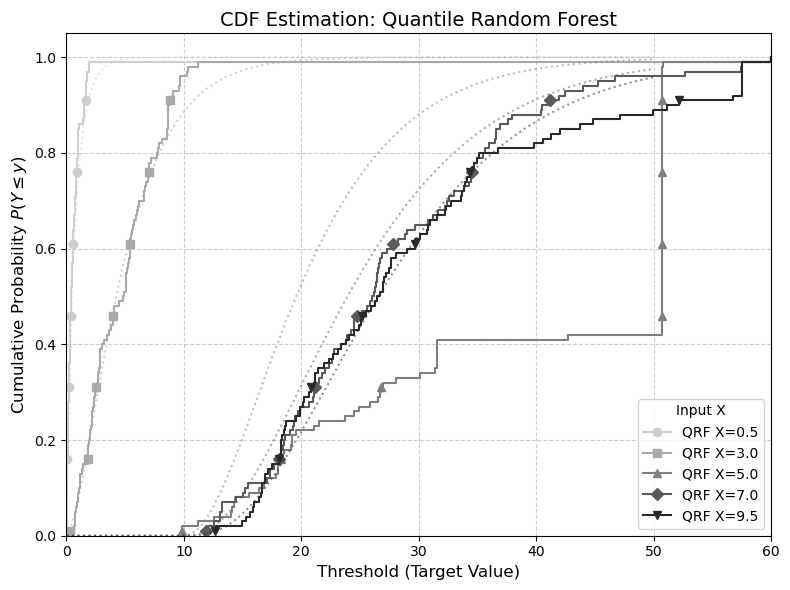

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm
from quantile_forest import RandomForestQuantileRegressor

# --- 1. Data & Parameter Setup ---
# Assuming X and y are already defined in your environment
ls_q = [0.01 * (i + 1) for i in range(99)]
x_test = np.array([0.5, 3, 5, 7, 9.5]).reshape(-1, 1)
markers = ['o', 's', '^', 'D', 'v']

# --- 2. Model Training (Quantile Random Forest) ---
# QRF aggregates the distribution of samples in the leaf nodes
qrf = RandomForestQuantileRegressor(
    n_estimators=100, 
    max_depth=10, 
    min_samples_split=10, 
    random_state=42
)
qrf.fit(X.reshape(-1, 1), y)

# --- 3. Prediction ---
# res_qrf shape: (n_test_samples, n_quantiles)
res_qrf = qrf.predict(x_test, quantiles=ls_q)

# --- 4. Plotting with plt.step ---
plt.figure(figsize=(8, 6))
cmap = matplotlib.cm.get_cmap('Greys')

for i, x_i in enumerate(x_test[:, 0]):
    color = cmap(0.3 + 0.7 * i / x_test.shape[0])
    
    # Extract predicted thresholds for this specific x_test
    thresholds = res_qrf[i] 
    
    # Add a final point to ensure the CDF line extends to the edge of the plot
    # This mimics your 'ls_x.append(60)' logic
    plot_x = np.append(thresholds, 60)
    plot_y = np.append(ls_q, 1.0)

    # Use plt.step for the "Staircase" effect
    # 'where=post' means the jump happens at the START of the interval
    plt.step(
        plot_x, 
        plot_y, 
        where='post', 
        color=color, 
        linestyle='-', 
        marker=markers[i % len(markers)], 
        markevery=15, 
        markersize=6, 
        label=f'QRF X={x_i}'
    )

    # 5. Theoretical CDF (Dotted line for comparison)
    # Assuming get_cdf and mode are defined in your scope
    vals = np.linspace(0, 50, 100)
    plt.plot(
        vals, 
        get_cdf(x_i, vals, mode=mode), 
        color=color, 
        linestyle=':', 
        alpha=0.5
    )

# Formatting
plt.title('CDF Estimation: Quantile Random Forest', fontsize=14)
plt.xlabel('Threshold (Target Value)', fontsize=12)
plt.ylabel('Cumulative Probability $P(Y \leq y)$', fontsize=12)
plt.legend(title='Input X', loc='lower right', frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(0, 60)
plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm
from quantile_forest import RandomForestQuantileRegressor

# --- 1. Data & Parameter Setup ---
# Assuming X, y, get_cdf, and mode are already defined
ls_q = np.linspace(0.01, 0.99, 99)
x_test = np.array([0.5, 3, 5, 7, 9.5]).reshape(-1, 1)
markers = ['o', 's', '^', 'D', 'v']

# Ensure X has correct shape
X_train = X if X.ndim == 2 else X.reshape(-1, 1)

# --- 2. Model Training (Quantile Random Forest) ---
qrf = RandomForestQuantileRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    random_state=42
)
qrf.fit(X_train, y)

# --- 3. Prediction ---
# res_qrf shape: (n_test_samples, n_quantiles)
res_qrf = qrf.predict(x_test, quantiles=ls_q)

# Determine a safe right-edge for plotting
x_max = max(60, np.max(res_qrf) + 1)

# --- 4. Plotting with plt.step ---
plt.figure(figsize=(8, 6))
cmap = matplotlib.cm.get_cmap('Greys')

for i, x_i in enumerate(x_test[:, 0]):
    color = cmap(0.3 + 0.7 * i / max(1, x_test.shape[0] - 1))

    # Predicted quantiles for this x_test
    thresholds = res_qrf[i]

    # Optional: enforce monotonicity in case of numerical irregularities
    thresholds = np.maximum.accumulate(thresholds)

    # Extend to the right edge so the final plateau is visible
    plot_x = np.append(thresholds, x_max)
    plot_y = np.append(ls_q, 1.0)

    # 'where=post' means each y-value is held constant to the right;
    # the jump occurs at the current x-position.
    plt.step(
        plot_x,
        plot_y,
        where='post',
        color=color,
        linestyle='-',
        marker=markers[i % len(markers)],
        markevery=15,
        markersize=6,
        label=f'QRF X={x_i}'
    )

    # --- 5. Theoretical CDF (for comparison) ---
    vals = np.linspace(0, x_max, 200)
    plt.plot(
        vals,
        get_cdf(x_i, vals, mode=mode),
        color=color,
        linestyle=':',
        alpha=0.6
    )

# Formatting
plt.title('CDF Estimation: Quantile Random Forest', fontsize=14)
plt.xlabel('Threshold (Target Value)', fontsize=12)
plt.ylabel(r'Cumulative Probability $P(Y \leq y)$', fontsize=12)
plt.legend(title='Input X', loc='lower right', frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(0, x_max)
plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()